In [1]:
#Kurze Wh der Datenanalyse am Bsp des Titanic Datensatzes
#Fokus alleine auf Trainingsdaten, ist ja nur eine Wh ....

In [2]:
#load ALL packages already here and get data

import pandas as pd #for df
import matplotlib.pyplot as plt #for plots
import seaborn as sns #for charts
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from statsmodels.graphics.mosaicplot import mosaic
import os #for wd

targetDirectory = "C:\\CASES\\PYTPRA"
fileName = 'Titanic.csv'
os.chdir(targetDirectory)

print("Working directory in use: ", os. getcwd())

train = pd.read_csv(fileName)
train.head()

#Business understanding: What is the question? Forschungsfrage!
train = train.drop(['id', 'name','ticket','cabin','port_embarked'], axis=1)
train.head()

Working directory in use:  C:\CASES\PYTPRA


,sex,age,siblings_spouses,parents_children,travel_class,fare,survived
0,male,0.8333,1,1,2,18.75,1
1,female,14.0000,1,2,1,120.00,1
2,male,52.0000,0,0,1,30.50,1
3,male,22.0000,0,0,3,8.05,0
4,female,24.0000,2,1,2,27.00,1


In [3]:
# Berechnung der prozentualen Anzahl der fehlenden Werte pro Spalte
missing_percentage = (train.isna().mean() * 100).round(2)
# Ausgabe der prozentualen Anzahl der fehlenden Werte pro Spalte
print("Prozentuale Anzahl der fehlenden Werte pro Spalte:")
print(missing_percentage)

#just in case
#df['Age'].fillna(df['Age'].median(), inplace=True)
#df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# Converting data types
#df['Pclass'] = df['Pclass'].astype('category')
# Removing duplicates
#df.drop_duplicates(inplace=True)
# Correcting inconsistencies
#df.loc[df['Age'] < 0, 'Age'] = df['Age'].median()
# Filling in missing values
#df['Age'].fillna(df['Age'].median(), inplace=True)
#df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# Converting data types
#df['Pclass'] = df['Pclass'].astype('category')
#df.loc[df['Age'] < 0, 'Age'] = df['Age'].median()

Prozentuale Anzahl der fehlenden Werte pro Spalte:
sex                  0.00
age                 20.49
siblings_spouses     0.00
parents_children     0.00
travel_class         0.00
fare                 0.09
survived             0.00
dtype: float64


In [4]:
#as age is of interest we drop the rows with missing ages
train_clean = train
train_clean.dropna(axis=0, subset=["age"], inplace=True)
#last arg is very crucial
train_clean.head()
#check effect
print(train.shape)
print(train_clean.shape)# a riddle ????
# Berechnung der prozentualen Anzahl der fehlenden Werte pro Spalte
missing_percentage = (train_clean.isna().mean() * 100).round(2)
# Ausgabe der prozentualen Anzahl der fehlenden Werte pro Spalte
print("Prozentuale Anzahl der fehlenden Werte pro Spalte:")
print(missing_percentage)

(885, 7)
(885, 7)
Prozentuale Anzahl der fehlenden Werte pro Spalte:
sex                 0.00
age                 0.00
siblings_spouses    0.00
parents_children    0.00
travel_class        0.00
fare                0.11
survived            0.00
dtype: float64


In [5]:
#MANUALLY DECIDE which are the relevant metric vars and the categorical ones
#charts will be produced accordingly

print(train.describe())#hereby it gets clear which vars are metric

              age  siblings_spouses  parents_children  travel_class  \
count  885.000000        885.000000        885.000000    885.000000   
mean    30.094068          0.483616          0.412429      2.212429   
std     14.373612          0.899354          0.836432      0.841556   
min      0.166700          0.000000          0.000000      1.000000   
25%     21.000000          0.000000          0.000000      1.000000   
50%     28.000000          0.000000          0.000000      2.000000   
75%     39.000000          1.000000          1.000000      3.000000   
max     80.000000          8.000000          6.000000      3.000000   

             fare    survived  
count  884.000000  885.000000  
mean    35.651659    0.404520  
std     52.216148    0.491076  
min      0.000000    0.000000  
25%      8.050000    0.000000  
50%     15.525000    0.000000  
75%     35.500000    1.000000  
max    512.329200    1.000000  


In [6]:
# Mapping for label encoding
sex_mapping = {'male': 0, 'female': 1}
train['sex'] = train['sex'].map(sex_mapping)
train.head()

,sex,age,siblings_spouses,parents_children,travel_class,fare,survived
0,0,0.8333,1,1,2,18.75,1
1,1,14.0000,1,2,1,120.00,1
2,0,52.0000,0,0,1,30.50,1
3,0,22.0000,0,0,3,8.05,0
4,1,24.0000,2,1,2,27.00,1


In [7]:
listOfMetricVars = ("age", "siblings_spouses", "parents_children", "fare")
listOfCategoricalVars = ("sex", "travel_class", "survived")
#technically metric but only 0 or 1
print("done with separation into metric and cat")

done with separation into metric and cat


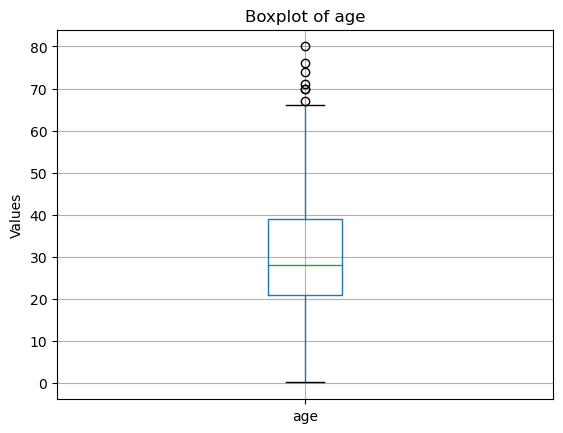

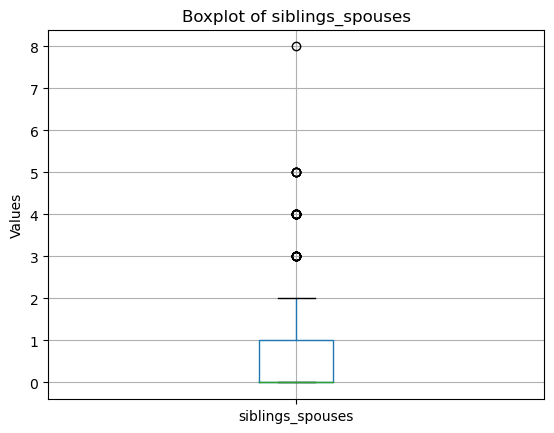

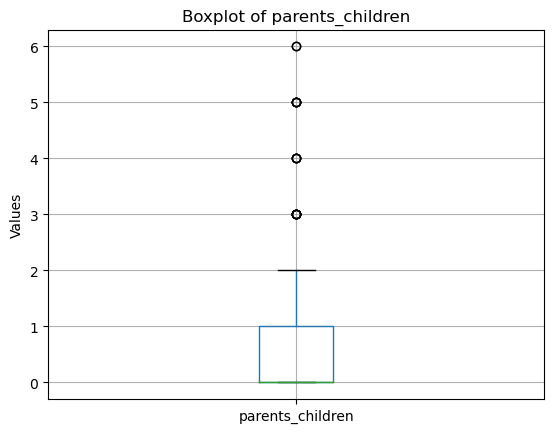

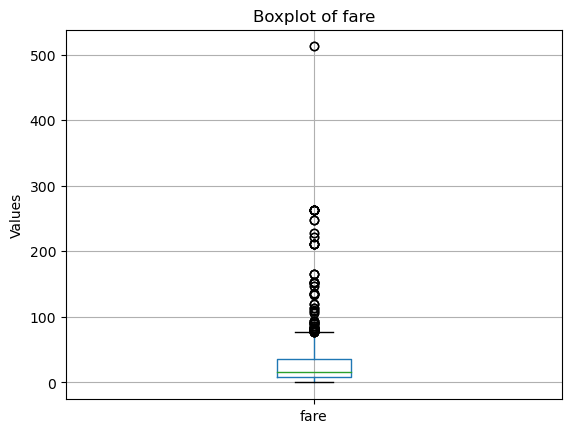

In [8]:
#charting vars individually
# Plot boxplots for each column individually
plt.figure()#figsize=(12, 8))
for column in listOfMetricVars:
    train_clean.boxplot(column=column)
    plt.title(f'Boxplot of {column}')
    plt.ylabel('Values')
    plt.show()

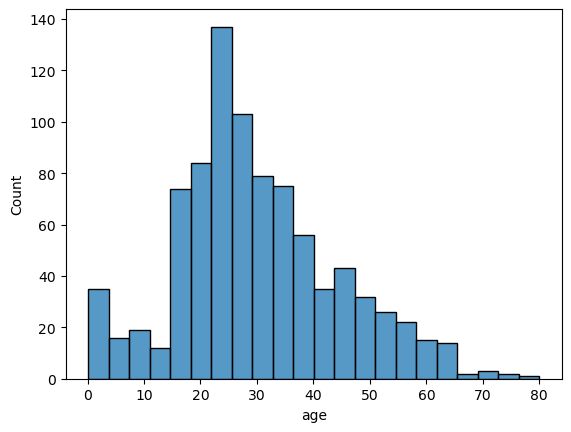

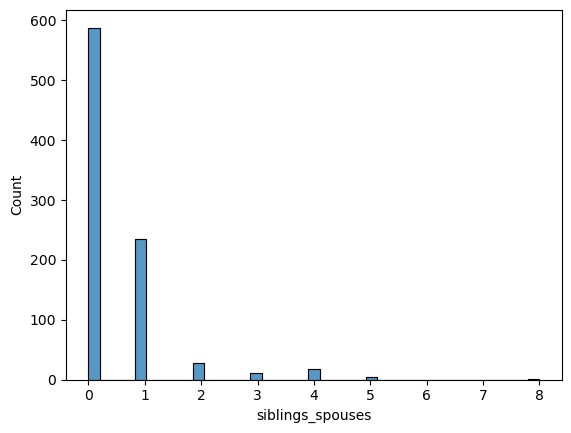

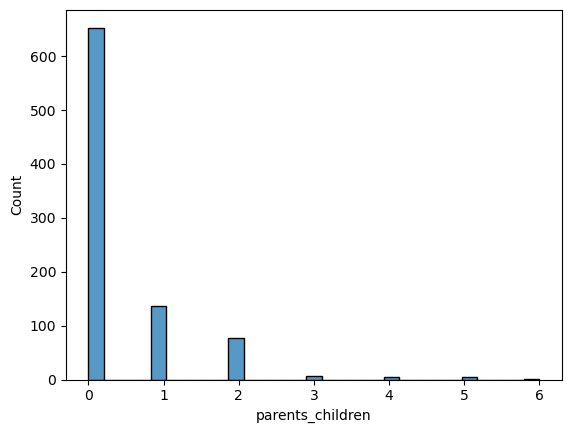

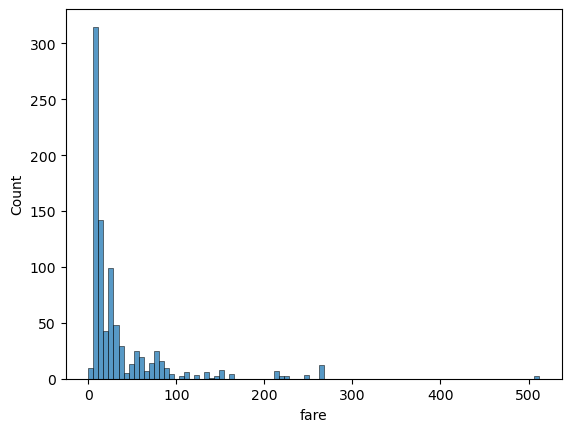

In [9]:
#charting vars individually histogram
#https://seaborn.pydata.org/generated/seaborn.histplot.html
plt.figure()#figsize=(12, 8))
for column in listOfMetricVars:
    sns.histplot(data=train_clean, x=column)
    plt.show()  


In [10]:
#quantify non-normality
for column in listOfMetricVars:
    print(train_clean.agg(
        {

        column: ["min", "median", "mean", "max", "skew", "kurtosis"],

        }
))
#positive skew = mean above median, i.e. data spreads more to the right side
#Kurtosis obtained using Fisher’s definition of kurtosis (kurtosis of normal == 0.0). 

                age
min        0.166700
median    28.000000
mean      30.094068
max       80.000000
skew       0.417608
kurtosis   0.151552
          siblings_spouses
min               0.000000
median            0.000000
mean              0.483616
max               8.000000
skew              2.971533
kurtosis         12.069620
          parents_children
min               0.000000
median            0.000000
mean              0.412429
max               6.000000
skew              2.766138
kurtosis         10.171281
                fare
min         0.000000
median     15.525000
mean       35.651659
max       512.329200
skew        3.867137
kurtosis   21.149090


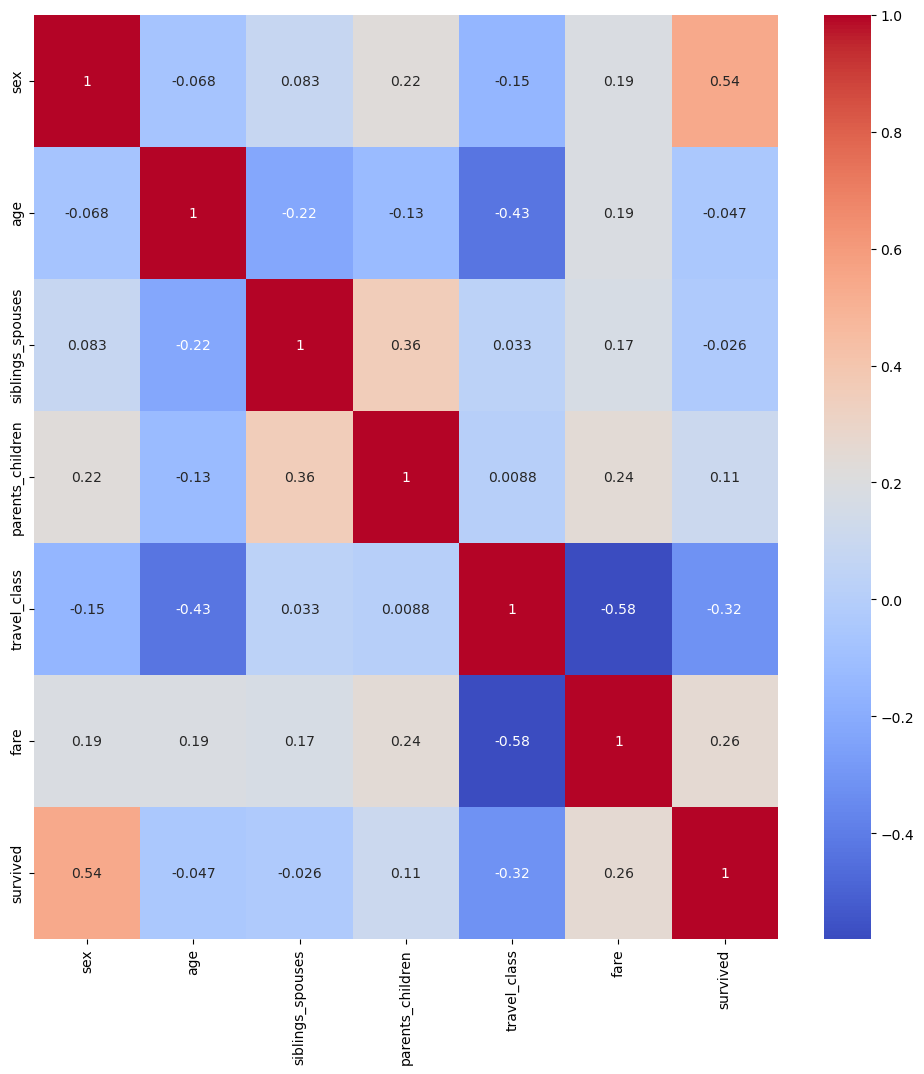

In [11]:
corr_matrix = train.corr()

plt.figure(figsize=(12, 12))  # Optional: Größe der Heatmap anpassen
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")  # annot=True zeigt die Werte in der Heatmap an
plt.show()

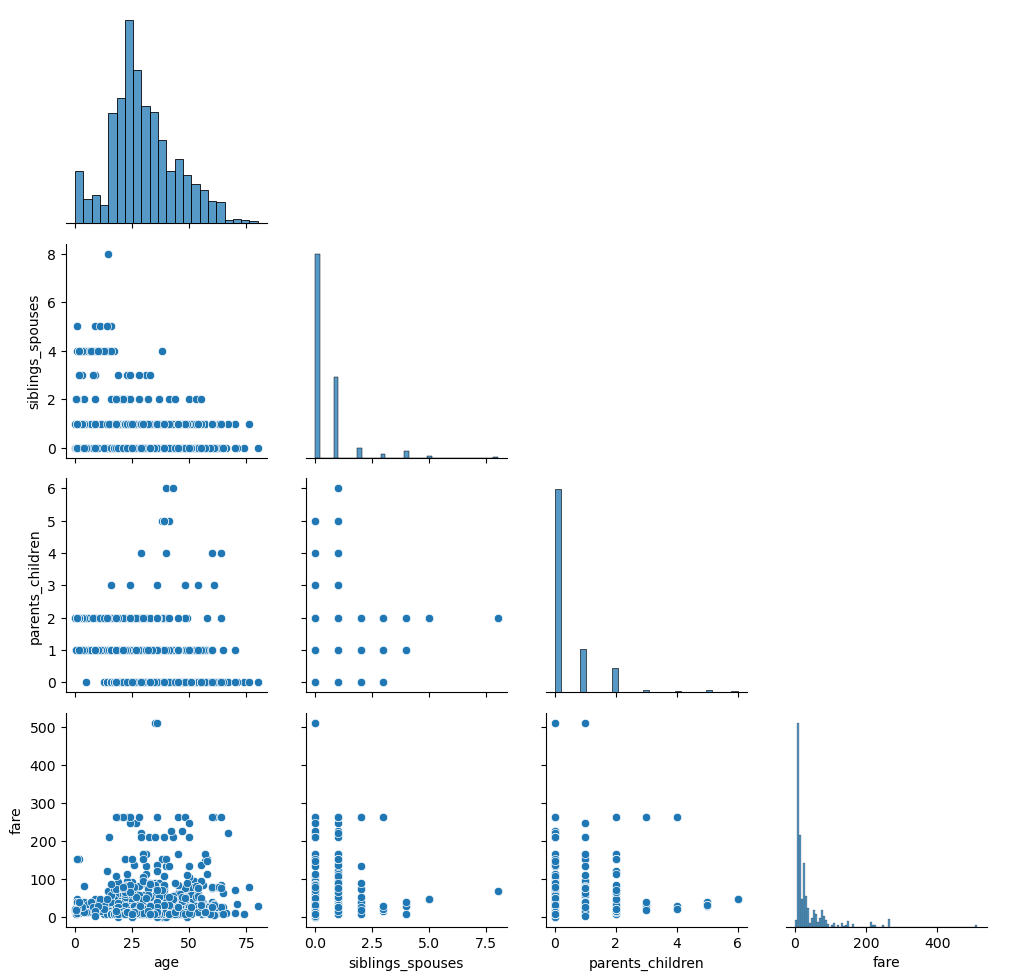

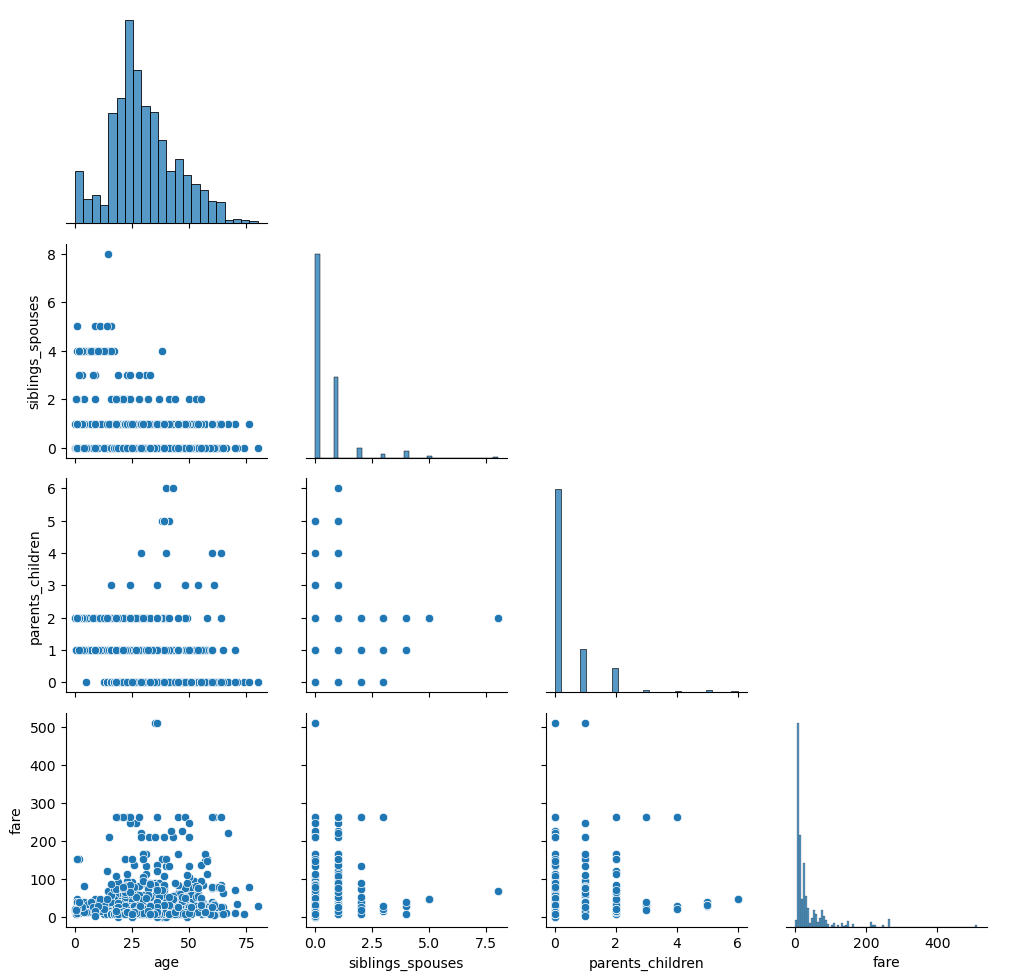

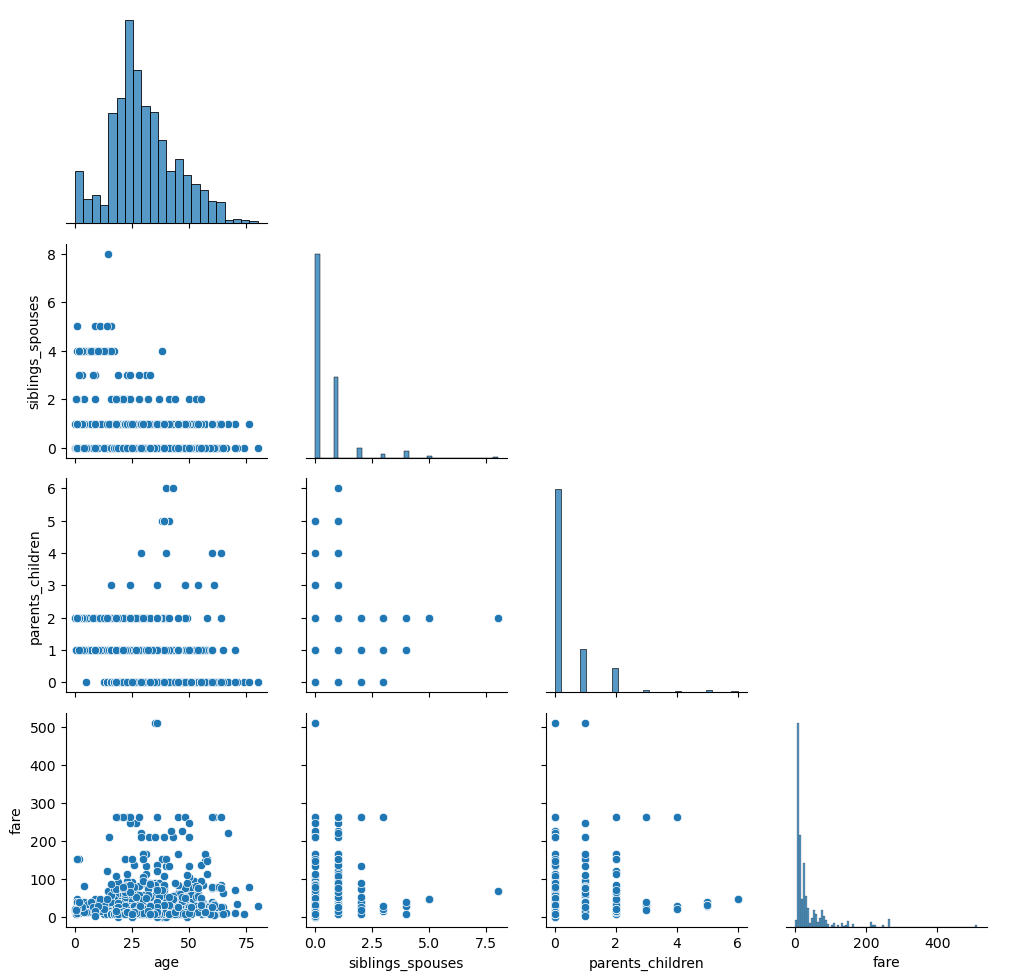

In [12]:
#Start looking for depds
for i in range(0, (len(listOfCategoricalVars))):
    g = sns.PairGrid(train, vars = listOfMetricVars, diag_sharey=False, corner=True)#last arg avoids redundancy
    g.map_diag(sns.histplot)
    g.map_offdiag(sns.scatterplot)
    g.add_legend()

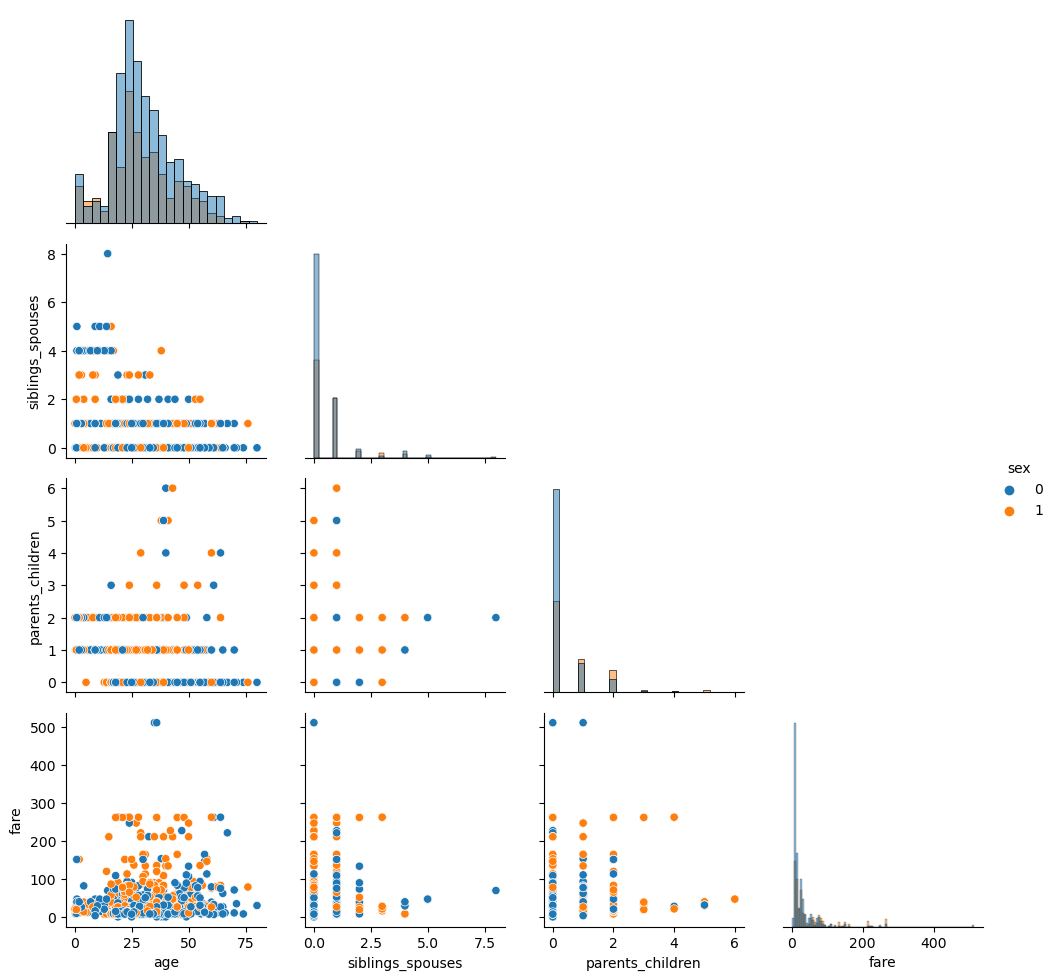

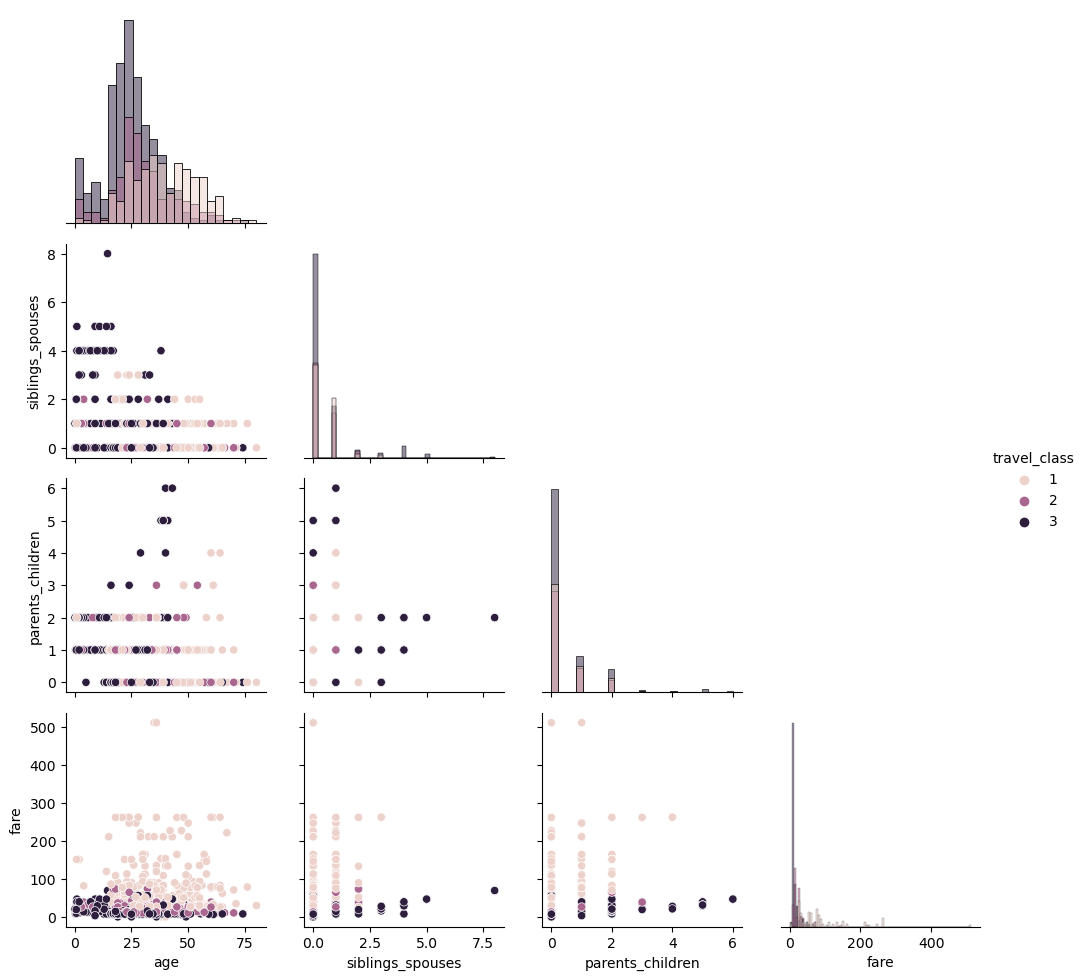

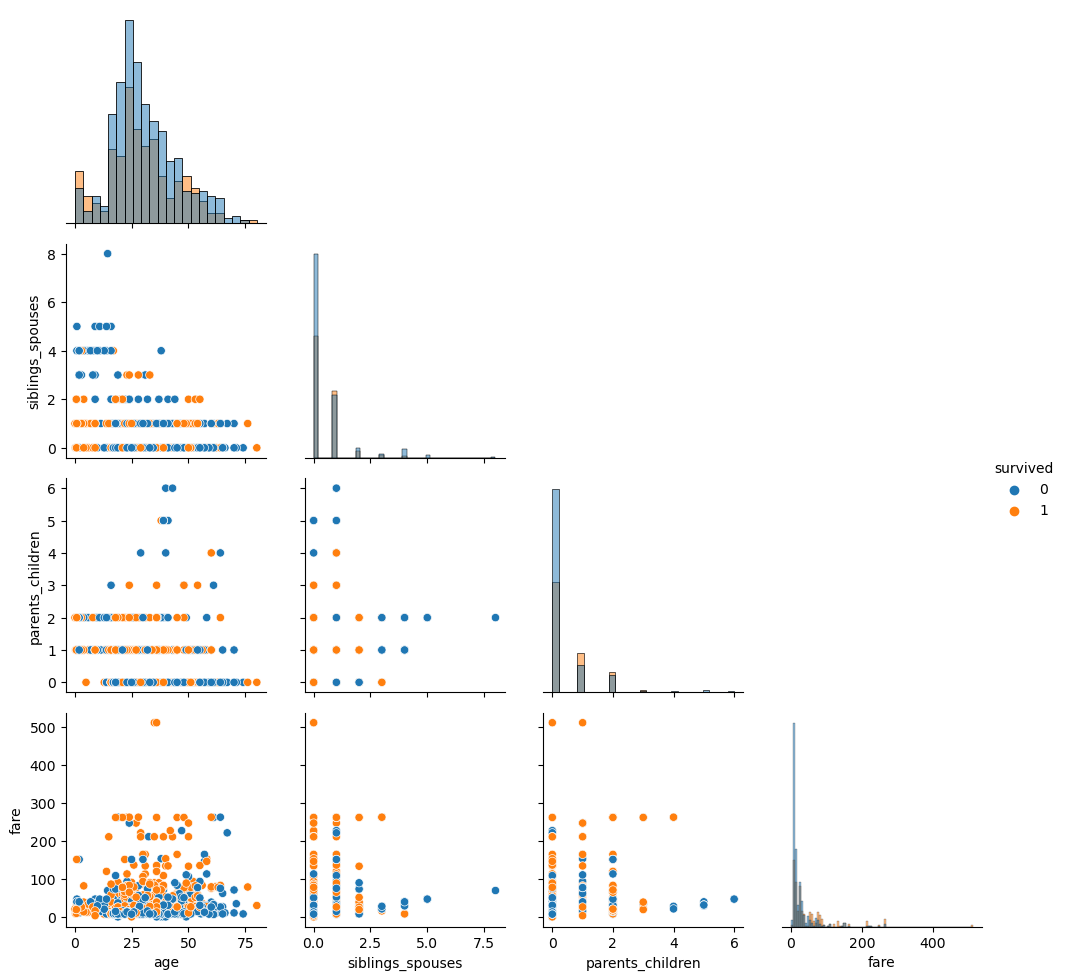

In [13]:
#Start looking for depds conditioned on categories
for i in range(0, (len(listOfCategoricalVars))):
    g = sns.PairGrid(train, vars = listOfMetricVars, hue=listOfCategoricalVars[i],  diag_sharey=False, corner=True)#last arg avoids redundancy
    g.map_diag(sns.histplot)
    g.map_offdiag(sns.scatterplot)
    g.add_legend()

In [14]:
#now go for survival factors
train_clean.groupby('sex')[['survived']].mean()

,survived
sex,
0,0.198182
1,0.743284


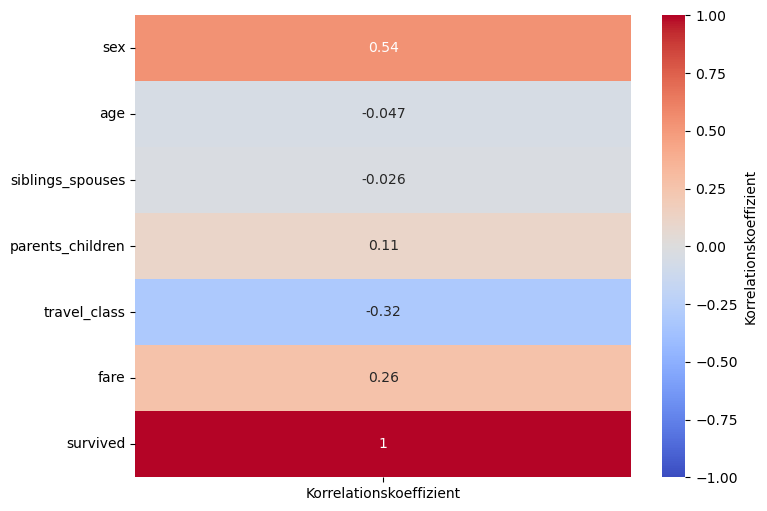

In [15]:
correlation_matrix = train.corrwith(train['survived']).to_frame(name='Korrelationskoeffizient')

# Erstellen der Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label': 'Korrelationskoeffizient'})
plt.show()

In [16]:
train_clean.groupby(['sex', 'travel_class'])['survived'].aggregate('mean').unstack()

travel_class,1,2,3
sex,,,
0,0.317073,0.150376,0.170068
1,0.965517,0.883721,0.458647


In [17]:
age = pd.cut(train_clean['age'], [0, 18, 80])
train_clean.pivot_table('survived', ['sex', age], 'travel_class')

travel_class         1         2         3
sex age                                   
0   (0, 18]   0.500000  0.588235  0.220339
    (18, 80]  0.310924  0.086207  0.157447
1   (0, 18]   0.909091  0.928571  0.529412
    (18, 80]  0.971429  0.875000  0.414634

###################### CONFUSION MATRIX BASED ON sex
Accuracy: 0.78


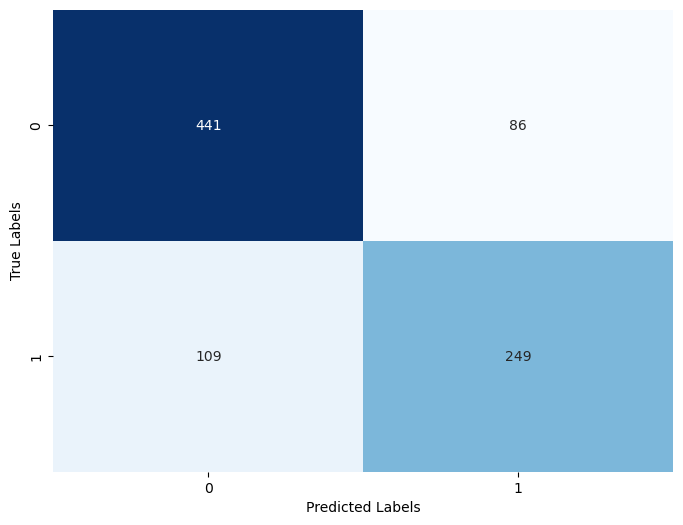

###################### CONFUSION MATRIX BASED ON travel_class
Accuracy: 0.17


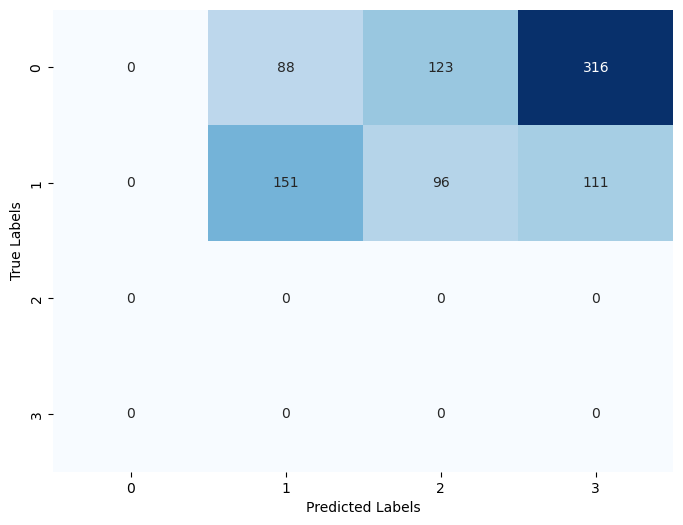

In [18]:
#Start looking for depds intra categories with focus survived
y_true = train_clean["survived"]
for i in range(0, (len(listOfCategoricalVars))):
    # Compute confusion matrix
    if listOfCategoricalVars[i] != "survived":
        y_pred =  train_clean[listOfCategoricalVars[i]]#use this category to forecast survival
        conf_matrix = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        print("###################### CONFUSION MATRIX BASED ON", listOfCategoricalVars[i])
        accuracy_eval = accuracy_score(y_true, y_pred)
        print("Accuracy:", accuracy_eval.round(2))
        plt.show()    

In [19]:
#Start looking for depds intra categories with focus survived
train_categorical = train_clean
for i in range(0, (len(listOfCategoricalVars))):
    train_categorical[listOfCategoricalVars[i]] = train_categorical[listOfCategoricalVars[i]].astype('category') 


###################### MOSAIC MATRIX BASED ON sex


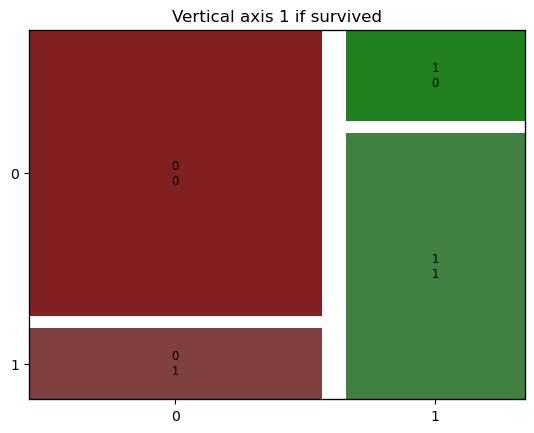

###################### MOSAIC MATRIX BASED ON travel_class


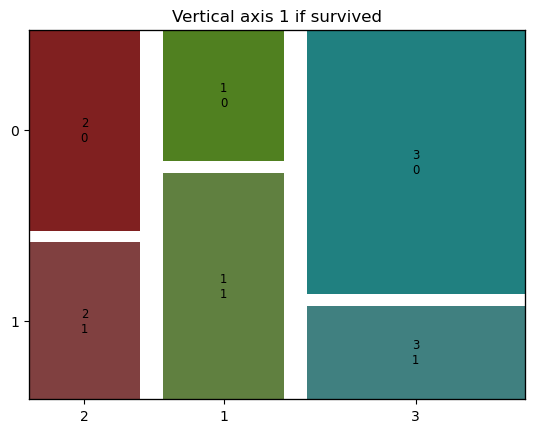

In [20]:
#props = lambda key: {'color': 'r' if 'survived' in key else 'gray'}
for i in range(0, (len(listOfCategoricalVars))):
    # Compute confusion matrix
    if listOfCategoricalVars[i] != "survived":
        print("###################### MOSAIC MATRIX BASED ON", listOfCategoricalVars[i])
        mosaic(train_categorical, [(listOfCategoricalVars[i]),'survived'], title='Vertical axis 1 if survived', gap=0.05)
        plt.show()
